In [2]:
import pandas as pd
import numpy as np

train_df = pd.read_csv("C:\\Users\\erons\\saas-churn-prediction\\data\\processed\\churn_features.csv")
train_df.head()

,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Churn,Total usage minutes,Total calls,Service call ratio
0,128,0,1,25,265.1,110,197.4,99,244.7,91,10.0,3,1,False,717.2,303,0.003300
1,107,0,1,26,161.6,123,195.5,103,254.4,103,13.7,3,1,False,625.2,332,0.003012
2,137,0,0,0,243.4,114,121.2,110,162.6,104,12.2,5,0,False,539.4,333,0.000000
3,84,1,0,0,299.4,71,61.9,88,196.9,89,6.6,7,2,False,564.8,255,0.007843
4,75,1,0,0,166.7,113,148.3,122,186.9,121,10.1,3,3,False,512.0,359,0.008357


## Prepare Features and Target

## Applying Feature Engineering to Test Data

To ensure consistency between training and testing, the same feature engineering steps applied to the training dataset are manually applied to the test dataset.

This ensures that both datasets have identical feature representations, which is critical for accurate model evaluation.

The test dataset is processed independently to avoid data leakage and to simulate real-world deployment conditions.

## Load Raw Test Data

In [3]:
test_df = pd.read_csv("C:\\Users\\erons\\saas-churn-prediction\\data\\raw\\churn-bigml-20.csv")

In [4]:
#Drop same columns as in training data
test_df = test_df.drop(columns=[
    "Total day charge",
    "Total eve charge",
    "Total night charge",
    "Total intl charge"
])

In [5]:
#drop the "state" column
test_df = test_df.drop(columns=["State"])

In [6]:
test_df = test_df.drop(columns=["Area code"])

In [7]:
test_df["International plan"] = test_df["International plan"].map({"No":0, "Yes":1})
test_df["Voice mail plan"] = test_df["Voice mail plan"].map({"No":0, "Yes":1})

In [8]:
test_df["Total usage minutes"] = (
    test_df["Total day minutes"] +
    test_df["Total eve minutes"] +
    test_df["Total night minutes"] +
    test_df["Total intl minutes"]
)

In [9]:
test_df["Total calls"] = (
    test_df["Total day calls"] +
    test_df["Total eve calls"] +
    test_df["Total night calls"] +
    test_df["Total intl calls"]
)

In [10]:
test_df["Service call ratio"] = test_df["Customer service calls"] / test_df["Total calls"]

In [11]:
#save processed test data
test_df.to_csv("C:\\Users\\erons\\saas-churn-prediction\\data\\processed\\churn_test_features.csv", index=False)

In [12]:
#Load test data
test_df = pd.read_csv("C:\\Users\\erons\\saas-churn-prediction\\data\\processed\\churn_test_features.csv")
test_df.head()

,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Churn,Total usage minutes,Total calls,Service call ratio
0,117,0,0,0,184.5,97,351.6,80,215.8,90,8.7,4,1,False,760.6,271,0.003690
1,65,0,0,0,129.1,137,228.5,83,208.8,111,12.7,6,4,True,579.1,337,0.011869
2,161,0,0,0,332.9,67,317.8,97,160.6,128,5.4,9,4,True,816.7,301,0.013289
3,111,0,0,0,110.4,103,137.3,102,189.6,105,7.7,6,2,False,445.0,316,0.006329
4,49,0,0,0,119.3,117,215.1,109,178.7,90,11.1,1,1,False,524.2,317,0.003155


## Define Train and Test

In [13]:
X_train = train_df.drop("Churn", axis=1)
y_train = train_df["Churn"]

X_test = test_df.drop("Churn", axis=1)
y_test = test_df["Churn"]

## Train the Base Model

In [14]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=3000, solver="lbfgs")
)

model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=3000))])

In [15]:
model.named_steps["logisticregression"].n_iter_

array([21], dtype=int32)

## Make Predictions

In [16]:
y_pred = model.predict(X_test)

## Evaluate the Model

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.88      0.97      0.92       572
        True       0.47      0.19      0.27        95

    accuracy                           0.85       667
   macro avg       0.68      0.58      0.59       667
weighted avg       0.82      0.85      0.83       667



Although the model achieves 85% accuracy, it performs poorly on the minority class with a recall of 0.19. This indicates severe class imbalance, and the model fails to capture the positive class effectively. I would try to address this using class weighting, resampling techniques, and threshold tuning

In [18]:
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=3000, solver="lbfgs", class_weight="balanced")
)

model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(class_weight='balanced', max_iter=3000))])

In [19]:
y_pred_logistic = model.predict(X_test)

In [20]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

       False       0.95      0.78      0.86       572
        True       0.37      0.77      0.50        95

    accuracy                           0.78       667
   macro avg       0.66      0.77      0.68       667
weighted avg       0.87      0.78      0.81       667



## Handling Class Imbalance

The initial logistic regression model performed poorly in identifying churned customers, with a recall of only 0.19 for the churn class.

To address class imbalance, the model was retrained using class_weight="balanced". This significantly improved recall for churned customers to 0.77, indicating that the model is now able to identify a much larger proportion of customers at risk of churning.

Although precision decreased, this trade-off is acceptable in a churn prediction context, where identifying at-risk customers is more important than minimizing false positives.

This is much better because in a churn prediction, missing a churner is worse than a false alarm. 

Next, we move on to use more sophisticated methods to predict churn. We will begin with a Random Forest Classifier


In [21]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

### Train the Model

In [22]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [23]:
y_pred_rf = rf_model.predict(X_test)

### Evaluate 

In [24]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

       False       0.97      0.99      0.98       572
        True       0.95      0.81      0.88        95

    accuracy                           0.97       667
   macro avg       0.96      0.90      0.93       667
weighted avg       0.97      0.97      0.97       667



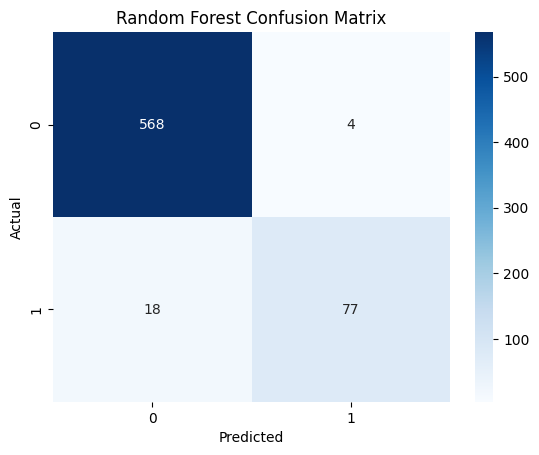

In [25]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues") 

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [26]:
 #Model Comparison table
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
models = {
    "Logistic Regression": y_pred_logistic,
    "Random Forest": y_pred_rf
}
metrics = {
    "Accuracy": accuracy_score,
    "Precision": precision_score,
    "Recall": recall_score,
    "F1-Score": f1_score
}
results = {}
for model_name, predictions in models.items():
    results[model_name] = {
        metric_name: metric_func(y_test, predictions)
        for metric_name, metric_func in metrics.items()
    }
results_df = pd.DataFrame(results).T
print(results_df)

                     Accuracy  Precision    Recall  F1-Score
Logistic Regression  0.779610   0.368687  0.768421  0.498294
Random Forest        0.967016   0.950617  0.810526  0.875000


In [27]:
#Feature importance for random forest
importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)
print(feature_importance_df)

                   Feature  Importance
4        Total day minutes    0.161292
13     Total usage minutes    0.146792
1       International plan    0.104305
12  Customer service calls    0.100566
15      Service call ratio    0.085436
10      Total intl minutes    0.057197
6        Total eve minutes    0.054096
8      Total night minutes    0.045462
11        Total intl calls    0.039607
0           Account length    0.034948
14             Total calls    0.034055
5          Total day calls    0.031245
7          Total eve calls    0.031120
9        Total night calls    0.029980
3    Number vmail messages    0.025571
2          Voice mail plan    0.018329


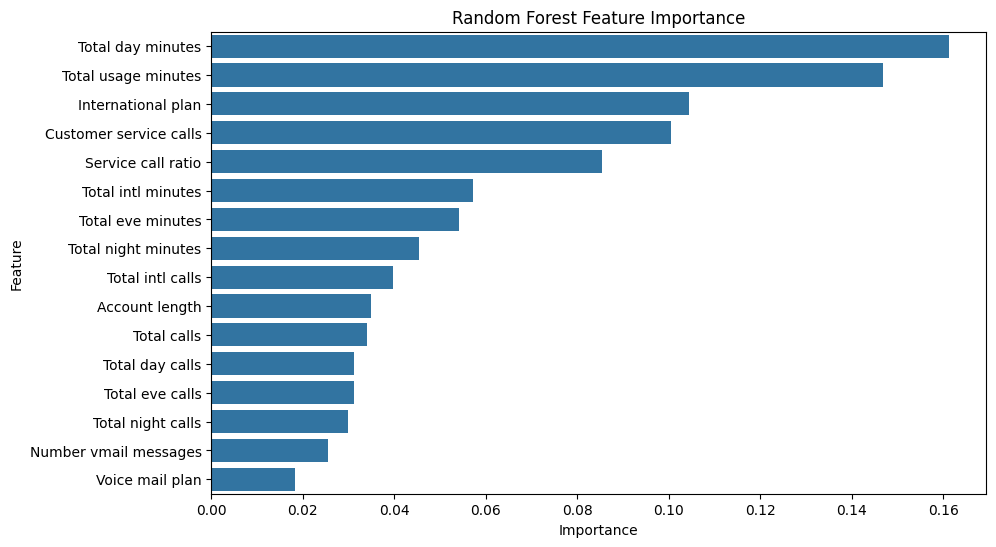

In [28]:
#Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Random Forest Feature Importance")
plt.show()

## Random Forest Model

A Random Forest classifier was trained to capture non-linear relationships in the data. Unlike logistic regression, Random Forest does not require feature scaling and can model complex interactions between variables.

The model was also trained with class_weight="balanced" to address class imbalance and improve the detection of churned customers.

Feature importance analysis reveals the most influential variables contributing to churn prediction.
These are Total day minutes, Total Usage minutes, International Plan, Customer service calls.
As suspected, users with high usage volume are the most churners, meaning they were most likely unsatisfied with their huge bills.

Next, we will train an Train XGBoost (Gradient Boosting) model and compare the evaluation to our previous models.

In [29]:
#Train Train XGBoost (Gradient Boosting)
from xgboost import XGBClassifier
xgb_model = XGBClassifier( 
    n_estimators=100,
    scale_pos_weight= (y_train == 0).sum() / (y_train == 1).sum(), #Handles class imbalance
    random_state=42
)   
xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [30]:
y_pred_xgboost = xgb_model.predict(X_test)

In [31]:
print(confusion_matrix(y_test, y_pred_xgboost))
print(classification_report(y_test, y_pred_xgboost))

[[564   8]
 [ 16  79]]
              precision    recall  f1-score   support

       False       0.97      0.99      0.98       572
        True       0.91      0.83      0.87        95

    accuracy                           0.96       667
   macro avg       0.94      0.91      0.92       667
weighted avg       0.96      0.96      0.96       667



In [32]:
#Optimize threshold for XGBoost - default threshold is 0.5, but we can adjust it to improve recall 

y_probs = xgb_model.predict_proba(X_test)[:,1]

y_pred_03 = (y_probs > 0.3).astype(int)

In [33]:
print(confusion_matrix(y_test, y_pred_03))
print(classification_report(y_test, y_pred_03))

[[563   9]
 [ 15  80]]
              precision    recall  f1-score   support

       False       0.97      0.98      0.98       572
        True       0.90      0.84      0.87        95

    accuracy                           0.96       667
   macro avg       0.94      0.91      0.92       667
weighted avg       0.96      0.96      0.96       667



### Insight
I used XGBoost with class imbalance handling via scale_pos_weight.
Then I optimized the decision threshold to improve recall, since missing churners is more costly than false positives.
This allowed me to reduce false negatives while maintaining strong precision.

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

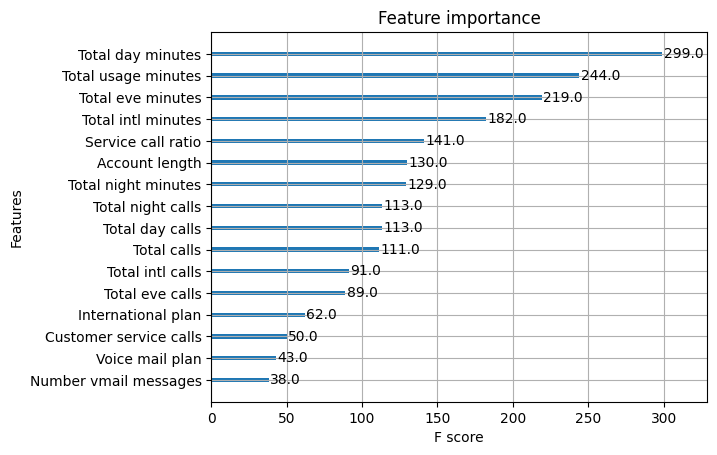

In [34]:
from xgboost import plot_importance
plot_importance(xgb_model)

In [ ]:
"""
Based on churn prediction, **XGBoost with the 0.3 threshold** is the best choice.

- It is the strongest option for the **minority churn class**
- It improves **recall**, which matters most here
- It keeps **precision** reasonably high

If the goal were only overall accuracy, the comparison could be different. For churn, **recall on churners should be the main metric**, and XGBoost is the best fit.
"""

SyntaxError: invalid syntax (2108519424.py, line 1)